In [60]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [61]:
# implement global variables at some point
TICKER = "SPY"

In [62]:
def upload_data(ticker):
    try:
        data = yf.download(ticker, '2019-01-01', '2026-01-01')
    except Exception as e:
        print(f"this ticker information is unavailable", {e})
    else:
        return pd.DataFrame(data)

In [63]:
upload_data("SPY")

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
Date,,,,,
2019-01-02,224.382553,225.306357,220.588736,220.615641,126925200
2019-01-03,219.028107,222.938523,218.543782,222.633571,144140700
2019-01-04,226.364639,227.010397,221.682902,222.059592,142628800
2019-01-07,228.149445,229.557546,225.736823,226.633708,103139100
2019-01-08,230.292999,230.777325,227.808639,230.337860,102512600
...,...,...,...,...,...
2025-12-24,688.499695,688.948481,685.926705,686.076320,39445600
2025-12-26,688.429871,689.776169,687.392725,688.758989,41613300


In [64]:
df = upload_data("SPY")

def plot_data(data):
    df["Close"].plot()
    plt.ylabel("Closing Price in USD$")
    plt.grid(True)
    plt.show()

[*********************100%***********************]  1 of 1 completed


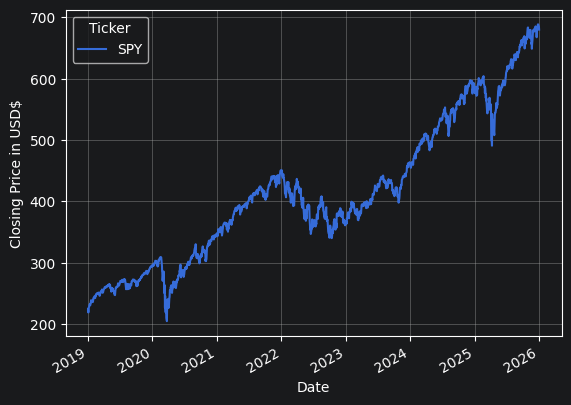

In [65]:
plot_data(df)

In [66]:
#calculate the moving average across a portion of the dataset

In [67]:
def three_day_moving_average_calculation(df):
    try:
        df["3MA"] = df.loc[:, "Close"].rolling(window=3).mean()
        return df
    except Exception as e:
        print(f"an error has occurred: {e}")
    finally:
        print("3 day moving average")

In [68]:
three_day_moving_average_calculation(df)

3 day moving average


Price,Close,High,Low,Open,Volume,3MA
Ticker,SPY,SPY,SPY,SPY,SPY,
Date,,,,,,
2019-01-02,224.382553,225.306357,220.588736,220.615641,126925200,NaN
2019-01-03,219.028107,222.938523,218.543782,222.633571,144140700,NaN
2019-01-04,226.364639,227.010397,221.682902,222.059592,142628800,223.258433
2019-01-07,228.149445,229.557546,225.736823,226.633708,103139100,224.514064
2019-01-08,230.292999,230.777325,227.808639,230.337860,102512600,228.269028
...,...,...,...,...,...,...
2025-12-24,688.499695,688.948481,685.926705,686.076320,39445600,685.850281
2025-12-26,688.429871,689.776169,687.392725,688.758989,41613300,687.671956


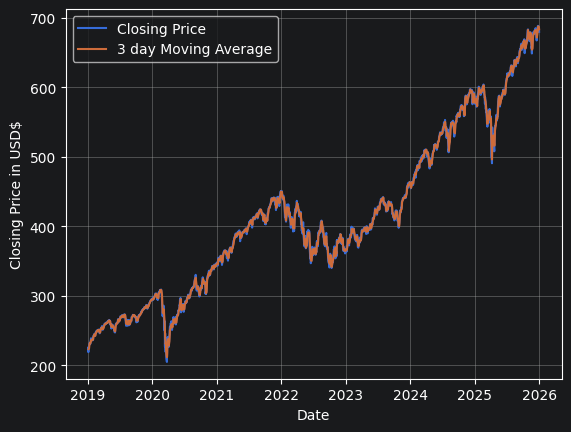

In [69]:
#plot the 3-day moving average
plt.plot(df["Close"], label="Closing Price")
plt.xlabel("Date")
plt.ylabel("Closing Price in USD$")
plt.plot(df["3MA"], label="3 day Moving Average")
plt.grid(True)
plt.legend(loc=2)
plt.show()

In [70]:
#calculate the 50-day moving average
def fifty_day_moving_average(df):
    try:
        df["50MA"] = df.loc[:, "Close"].rolling(window=50).mean()
        return df
    except Exception as e:
        print(f"an error has occurred:{e}")
    finally:
        print("50 day moving average")

In [71]:
fifty_day_moving_average(df)

50 day moving average


Price,Close,High,Low,Open,Volume,3MA,50MA
Ticker,SPY,SPY,SPY,SPY,SPY,,
Date,,,,,,,
2019-01-02,224.382553,225.306357,220.588736,220.615641,126925200,NaN,NaN
2019-01-03,219.028107,222.938523,218.543782,222.633571,144140700,NaN,NaN
2019-01-04,226.364639,227.010397,221.682902,222.059592,142628800,223.258433,NaN
2019-01-07,228.149445,229.557546,225.736823,226.633708,103139100,224.514064,NaN
2019-01-08,230.292999,230.777325,227.808639,230.337860,102512600,228.269028,NaN
...,...,...,...,...,...,...,...
2025-12-24,688.499695,688.948481,685.926705,686.076320,39445600,685.850281,673.116240
2025-12-26,688.429871,689.776169,687.392725,688.758989,41613300,687.671956,673.656758


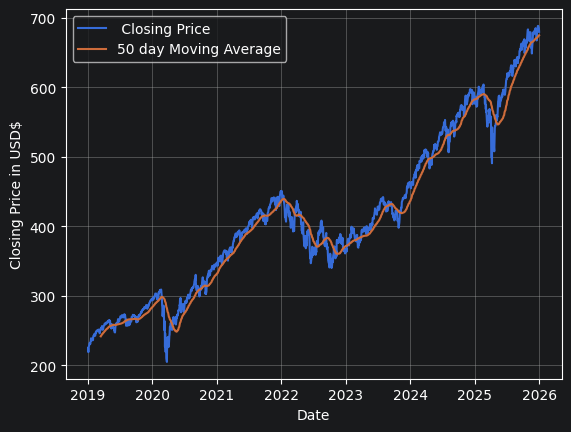

In [72]:
#plot the 50 day moving average
plt.plot(df["Close"], label=" Closing Price")
plt.plot(df["50MA"], label="50 day Moving Average")
plt.xlabel("Date")
plt.ylabel("Closing Price in USD$")
plt.grid(True)
plt.legend(loc=2)
plt.show()

In [73]:
# calculate and plot the 200-day moving average

In [74]:
df["200MA"] = df.loc[:, ["Close"]].rolling(window=200).mean()

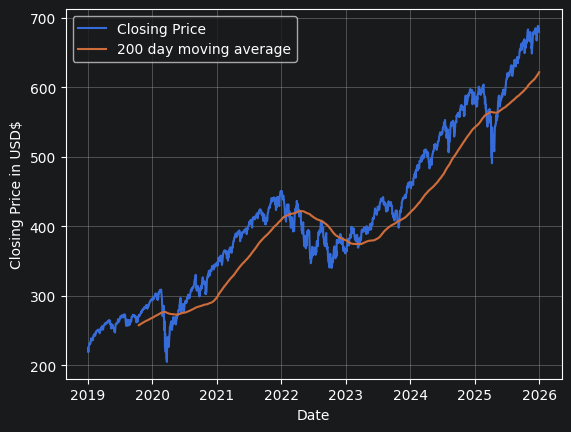

In [75]:
plt.plot(df["Close"], label="Closing Price")
plt.plot(df["200MA"], label="200 day moving average")
plt.xlabel("Date")
plt.ylabel("Closing Price in USD$")
plt.grid(True)
plt.legend(loc=2)
plt.show()

In [76]:
#plot the both the 3, 50 & 200 day moving average for the last 100 days of close price data
def moving_average_plots(df):
    df = df.iloc[-100:, :]
    plt.plot(df['Close'], label="Closing Price")
    plt.plot(df["3MA"],label="3 day moving average")
    plt.plot(df["50MA"], label="50 day moving average")
    plt.plot(df["200MA"], label="200 day moving average")
    plt.xlabel("Date")
    plt.ylabel("Closing Price in USD$")
    plt.grid(True)
    plt.legend(loc=2)
    plt.show()

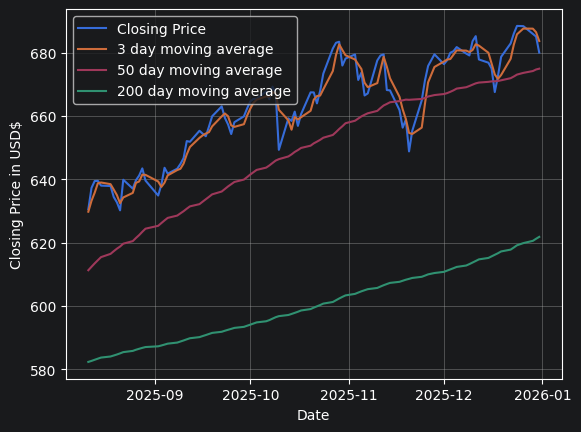

In [77]:
moving_average_plots(df)

In [78]:
# Formulate trading strategy using the moving average

# Take a long position if price > moving average (1)

# Take a short position if price < moving average (-1)

In [79]:
# remove the double header from each column of the data imported from yfinance
df.columns = df.columns.get_level_values(0)

In [80]:
df = df.dropna()

In [81]:
df

Price,Close,High,Low,Open,Volume,3MA,50MA,200MA
Date,,,,,,,,
2019-10-16,271.363892,272.055042,270.927399,271.336611,48928200,270.766764,266.526183,257.775196
2019-10-17,272.164185,273.037197,271.473034,272.527938,45736600,271.776164,266.755963,258.014104
2019-10-18,270.972870,272.273300,270.118035,271.627636,64304000,271.500315,266.859628,258.273828
2019-10-21,272.809937,273.010005,271.855081,272.291601,39048600,271.982330,267.036245,258.506054
2019-10-22,271.918701,273.637446,271.827756,273.346433,48594700,271.900503,267.259305,258.724901
...,...,...,...,...,...,...,...,...
2025-12-24,688.499695,688.948481,685.926705,686.076320,39445600,685.850281,673.116240,619.163893
2025-12-26,688.429871,689.776169,687.392725,688.758989,41613300,687.671956,673.656758,619.851648
2025-12-29,685.976562,687.322922,684.201442,685.667409,62559500,687.635376,674.238296,620.563855


In [82]:
def moving_average_strategy(df):
    df["Strategy"] = np.where(df["Close"] > df["200MA"], -1, 1)
    return df

In [83]:
df = moving_average_strategy(df)

In [84]:
df

Price,Close,High,Low,Open,Volume,3MA,50MA,200MA,Strategy
Date,,,,,,,,,
2019-10-16,271.363892,272.055042,270.927399,271.336611,48928200,270.766764,266.526183,257.775196,-1
2019-10-17,272.164185,273.037197,271.473034,272.527938,45736600,271.776164,266.755963,258.014104,-1
2019-10-18,270.972870,272.273300,270.118035,271.627636,64304000,271.500315,266.859628,258.273828,-1
2019-10-21,272.809937,273.010005,271.855081,272.291601,39048600,271.982330,267.036245,258.506054,-1
2019-10-22,271.918701,273.637446,271.827756,273.346433,48594700,271.900503,267.259305,258.724901,-1
...,...,...,...,...,...,...,...,...,...
2025-12-24,688.499695,688.948481,685.926705,686.076320,39445600,685.850281,673.116240,619.163893,-1
2025-12-26,688.429871,689.776169,687.392725,688.758989,41613300,687.671956,673.656758,619.851648,-1
2025-12-29,685.976562,687.322922,684.201442,685.667409,62559500,687.635376,674.238296,620.563855,-1


In [ ]:
# calculate the cumulative product of the asset & our strategy, and compare the two using a graph